# **AI advanced ahmed yousrey course practice**

****
#**DAY 1**

#**FOOD WASTE PREDICTION**
****

**STEP 1**

**IMPORTING LIBRARIES**

In [252]:
# ── Core ──────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ─────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Preprocessing ─────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
# ── Models ────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

# ── Evaluation ────────────────────────────────────────────
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ── Utilities ─────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

****
**STEP 2**

**IMPORTING DATABASE**
****

In [253]:
train_df = pd.read_csv('/content/train.csv')
test_df = pd.read_csv('/content/test.csv')

In [254]:
print('First 5 rows of training data:')
display(train_df.head())

print('\nFirst 5 rows of test data:')
display(test_df.head())

First 5 rows of training data:


,ID,date,meals_served,kitchen_staff,temperature_C,humidity_percent,day_of_week,special_event,past_waste_kg,staff_experience,waste_category,food_waste_kg
0,0,2022-12-19,196,13,27.887273,45.362854,0,0,7.740587,intermediate,dairy,28.946465
1,1,2023-11-21,244,15,10.317872,64.430475,1,0,42.311779,NaN,MeAt,51.549053
2,4,2022-02-01,148,16,27.714300,69.046113,1,0,41.184305,Beginner,MeAt,53.008323
3,5,2023-03-19,157,19,19.173902,46.292823,6,0,41.543492,Beginner,MeAt,48.621527
4,6,2022-07-18,297,10,26.375233,79.741064,0,0,26.525097,Intermediate,MEAT,44.156984



First 5 rows of test data:


,ID,date,meals_served,kitchen_staff,temperature_C,humidity_percent,day_of_week,special_event,past_waste_kg,staff_experience,waste_category
0,0,2022-12-19,196,13,27.887273,45.362854,0,0,7.740587,intermediate,dairy
1,1,2023-11-21,244,15,10.317872,64.430475,1,0,42.311779,NaN,MeAt
2,4,2022-02-01,148,16,27.714300,69.046113,1,0,41.184305,Beginner,MeAt
3,5,2023-03-19,157,19,19.173902,46.292823,6,0,41.543492,Beginner,MeAt
4,6,2022-07-18,297,10,26.375233,79.741064,0,0,26.525097,Intermediate,MEAT


****
**STEP 3**

**EDA**
****

In [255]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (911, 12)
Test shape: (911, 11)


In [256]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 911 entries, 0 to 910
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                911 non-null    int64  
 1   date              911 non-null    object 
 2   meals_served      911 non-null    int64  
 3   kitchen_staff     911 non-null    int64  
 4   temperature_C     911 non-null    float64
 5   humidity_percent  911 non-null    float64
 6   day_of_week       911 non-null    int64  
 7   special_event     911 non-null    int64  
 8   past_waste_kg     911 non-null    float64
 9   staff_experience  747 non-null    object 
 10  waste_category    911 non-null    object 
 11  food_waste_kg     911 non-null    float64
dtypes: float64(4), int64(5), object(3)
memory usage: 85.5+ KB


In [257]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 911 entries, 0 to 910
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                911 non-null    int64  
 1   date              911 non-null    object 
 2   meals_served      911 non-null    int64  
 3   kitchen_staff     911 non-null    int64  
 4   temperature_C     911 non-null    float64
 5   humidity_percent  911 non-null    float64
 6   day_of_week       911 non-null    int64  
 7   special_event     911 non-null    int64  
 8   past_waste_kg     911 non-null    float64
 9   staff_experience  747 non-null    object 
 10  waste_category    911 non-null    object 
dtypes: float64(3), int64(5), object(3)
memory usage: 78.4+ KB


In [258]:
train_df.describe()

,ID,meals_served,kitchen_staff,temperature_C,humidity_percent,day_of_week,special_event,past_waste_kg,food_waste_kg
count,911.000000,911.000000,911.000000,911.000000,911.000000,911.000000,911.000000,911.000000,911.000000
mean,528.327113,375.405049,11.900110,22.189280,60.761313,3.014270,0.085620,27.015691,44.842691
std,305.072794,502.812717,4.285153,8.922389,17.330821,2.009542,0.279956,12.774223,27.934366
min,0.000000,100.000000,5.000000,-10.372207,30.121111,0.000000,0.000000,5.008394,10.819048
25%,266.000000,211.000000,8.000000,15.684585,46.017835,1.000000,0.000000,16.091383,32.887912
50%,531.000000,306.000000,12.000000,22.115040,61.633960,3.000000,0.000000,26.854109,41.146930
75%,795.500000,407.000000,15.000000,28.804294,75.787910,5.000000,0.000000,38.149878,50.046681
max,1049.000000,4730.000000,19.000000,60.000000,89.982828,6.000000,1.000000,49.803703,274.328783


In [259]:
test_df.describe()

,ID,meals_served,kitchen_staff,temperature_C,humidity_percent,day_of_week,special_event,past_waste_kg
count,911.000000,911.000000,911.000000,911.000000,911.000000,911.000000,911.000000,911.000000
mean,528.327113,375.405049,11.900110,22.189280,60.761313,3.014270,0.085620,27.015691
std,305.072794,502.812717,4.285153,8.922389,17.330821,2.009542,0.279956,12.774223
min,0.000000,100.000000,5.000000,-10.372207,30.121111,0.000000,0.000000,5.008394
25%,266.000000,211.000000,8.000000,15.684585,46.017835,1.000000,0.000000,16.091383
50%,531.000000,306.000000,12.000000,22.115040,61.633960,3.000000,0.000000,26.854109
75%,795.500000,407.000000,15.000000,28.804294,75.787910,5.000000,0.000000,38.149878
max,1049.000000,4730.000000,19.000000,60.000000,89.982828,6.000000,1.000000,49.803703


In [260]:
train_df.isna().sum()

,0
ID,0
date,0
meals_served,0
kitchen_staff,0
temperature_C,0
humidity_percent,0
day_of_week,0
special_event,0
past_waste_kg,0
staff_experience,164


In [261]:
test_df.isna().sum()

,0
ID,0
date,0
meals_served,0
kitchen_staff,0
temperature_C,0
humidity_percent,0
day_of_week,0
special_event,0
past_waste_kg,0
staff_experience,164


In [262]:
train_df.duplicated().sum()

np.int64(0)

In [263]:
test_df.duplicated().sum()

np.int64(0)

EDA Summary

After performing the Exploratory Data Analysis, the following data quality issues were identified:

* Missing Values
  The dataset contains 164 missing values in the STAFF_experience column.

* Duplicate Values
  No duplicate rows were found in the dataset.

* Outliers
  Outliers were detected in the meals_served column.

* Data Types
  The (date ,STAFF_experience ,waste_category) column has a data type that may require further preprocessing before applying machine learning models.

Overall, the dataset is suitable for the next stage, which is data preprocessing. The identified missing values, data type issue, and outliers will be handled during preprocessing.


---
**STEP 4**

**REPORCESSING**

---

**handle outliers**

In [264]:
# ── Train: drop outliers ──────────────────────────────────
Q1 = train_df['meals_served'].quantile(0.25)
Q3 = train_df['meals_served'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

train_df = train_df[
    (train_df['meals_served'] >= lower_bound) &
    (train_df['meals_served'] <= upper_bound)
]

# ── Test: clip outliers (never drop rows from test) ───────
Q1 = test_df['meals_served'].quantile(0.25)
Q3 = test_df['meals_served'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

test_df['meals_served'] = test_df['meals_served'].clip(
    lower=lower_bound, upper=upper_bound
)

**handle mising value**

In [265]:
train_df['staff_experience'] = train_df['staff_experience'].fillna(
    train_df['staff_experience'].mode()[0]
)

test_df['staff_experience'] = test_df['staff_experience'].fillna(
    train_df['staff_experience'].mode()[0]
)

**fix data types**

1.date

In [266]:
train_df['date'] = pd.to_datetime(train_df['date'])
test_df['date'] = pd.to_datetime(test_df['date'])
train_df['date']

,date
0,2022-12-19
1,2023-11-21
2,2022-02-01
3,2023-03-19
4,2022-07-18
...,...
906,2022-03-29
907,2022-11-27
908,2023-04-12
909,2022-02-14


In [267]:
train_df['year'] = train_df['date'].dt.year
train_df['month'] = train_df['date'].dt.month
train_df['day'] = train_df['date'].dt.day
train_df.drop('date', axis=1, inplace=True)
train_df.head()

,ID,meals_served,kitchen_staff,temperature_C,humidity_percent,day_of_week,special_event,past_waste_kg,staff_experience,waste_category,food_waste_kg,year,month,day
0,0,196,13,27.887273,45.362854,0,0,7.740587,intermediate,dairy,28.946465,2022,12,19
1,1,244,15,10.317872,64.430475,1,0,42.311779,Beginner,MeAt,51.549053,2023,11,21
2,4,148,16,27.714300,69.046113,1,0,41.184305,Beginner,MeAt,53.008323,2022,2,1
3,5,157,19,19.173902,46.292823,6,0,41.543492,Beginner,MeAt,48.621527,2023,3,19
4,6,297,10,26.375233,79.741064,0,0,26.525097,Intermediate,MEAT,44.156984,2022,7,18


In [268]:
test_df['year'] = test_df['date'].dt.year
test_df['month'] = test_df['date'].dt.month
test_df['day'] = test_df['date'].dt.day
test_df.drop('date', axis=1, inplace=True)
test_df.head()

,ID,meals_served,kitchen_staff,temperature_C,humidity_percent,day_of_week,special_event,past_waste_kg,staff_experience,waste_category,year,month,day
0,0,196,13,27.887273,45.362854,0,0,7.740587,intermediate,dairy,2022,12,19
1,1,244,15,10.317872,64.430475,1,0,42.311779,Beginner,MeAt,2023,11,21
2,4,148,16,27.714300,69.046113,1,0,41.184305,Beginner,MeAt,2022,2,1
3,5,157,19,19.173902,46.292823,6,0,41.543492,Beginner,MeAt,2023,3,19
4,6,297,10,26.375233,79.741064,0,0,26.525097,Intermediate,MEAT,2022,7,18


2.staff_experience

In [269]:
train_df['staff_experience'].unique()

array(['intermediate', 'Beginner', 'Intermediate', 'EXPERT'], dtype=object)

In [270]:
# Apply one-hot encoding to 'staff_experience'
train_df['staff_experience'] = train_df['staff_experience'].astype(str).str.lower()
test_df['staff_experience'] = test_df['staff_experience'].astype(str).str.lower()

encoder_experience = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

train_encoded_experience = encoder_experience.fit_transform(train_df[['staff_experience']])
test_encoded_experience = encoder_experience.transform(test_df[['staff_experience']])

# Get feature names for the encoded 'staff_experience' columns
encoded_experience_feature_names = encoder_experience.get_feature_names_out(['staff_experience'])

# Create DataFrames from the encoded arrays
train_encoded_experience_df = pd.DataFrame(train_encoded_experience, columns=encoded_experience_feature_names, index=train_df.index)
test_encoded_experience_df = pd.DataFrame(test_encoded_experience, columns=encoded_experience_feature_names, index=test_df.index)

# Concatenate the encoded features with the original DataFrames
train_df = pd.concat([train_df, train_encoded_experience_df], axis=1)
test_df = pd.concat([test_df, test_encoded_experience_df], axis=1)

# Drop the original 'staff_experience' column
train_df.drop('staff_experience', axis=1, inplace=True)
test_df.drop('staff_experience', axis=1, inplace=True)

train_df.head()

,ID,meals_served,kitchen_staff,temperature_C,humidity_percent,day_of_week,special_event,past_waste_kg,waste_category,food_waste_kg,year,month,day,staff_experience_beginner,staff_experience_expert,staff_experience_intermediate
0,0,196,13,27.887273,45.362854,0,0,7.740587,dairy,28.946465,2022,12,19,0.0,0.0,1.0
1,1,244,15,10.317872,64.430475,1,0,42.311779,MeAt,51.549053,2023,11,21,1.0,0.0,0.0
2,4,148,16,27.714300,69.046113,1,0,41.184305,MeAt,53.008323,2022,2,1,1.0,0.0,0.0
3,5,157,19,19.173902,46.292823,6,0,41.543492,MeAt,48.621527,2023,3,19,1.0,0.0,0.0
4,6,297,10,26.375233,79.741064,0,0,26.525097,MEAT,44.156984,2022,7,18,0.0,0.0,1.0


In [271]:
train_df['waste_category'].unique()

array(['dairy', 'MeAt', 'MEAT', 'Vegetables', 'GRAINS'], dtype=object)

3.waste_category

In [272]:
train_df['waste_category'] = train_df['waste_category'].str.lower()
test_df['waste_category'] = test_df['waste_category'].str.lower()
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

train_encoded = encoder.fit_transform(train_df[['waste_category']])
test_encoded = encoder.transform(test_df[['waste_category']])

# Get feature names for the encoded columns
encoded_feature_names = encoder.get_feature_names_out(['waste_category'])

# Create DataFrames from the encoded arrays
train_encoded_df = pd.DataFrame(train_encoded, columns=encoded_feature_names, index=train_df.index)
test_encoded_df = pd.DataFrame(test_encoded, columns=encoded_feature_names, index=test_df.index)

# Concatenate the encoded features with the original DataFrames
train_df = pd.concat([train_df, train_encoded_df], axis=1)
test_df = pd.concat([test_df, test_encoded_df], axis=1)

# Drop the original 'waste_category' column
train_df.drop('waste_category', axis=1, inplace=True)
test_df.drop('waste_category', axis=1, inplace=True)

train_df.head()

,ID,meals_served,kitchen_staff,temperature_C,humidity_percent,day_of_week,special_event,past_waste_kg,food_waste_kg,year,month,day,staff_experience_beginner,staff_experience_expert,staff_experience_intermediate,waste_category_dairy,waste_category_grains,waste_category_meat,waste_category_vegetables
0,0,196,13,27.887273,45.362854,0,0,7.740587,28.946465,2022,12,19,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,1,244,15,10.317872,64.430475,1,0,42.311779,51.549053,2023,11,21,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,4,148,16,27.714300,69.046113,1,0,41.184305,53.008323,2022,2,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,5,157,19,19.173902,46.292823,6,0,41.543492,48.621527,2023,3,19,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,6,297,10,26.375233,79.741064,0,0,26.525097,44.156984,2022,7,18,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [273]:
train_df.describe()

,ID,meals_served,kitchen_staff,temperature_C,humidity_percent,day_of_week,special_event,past_waste_kg,food_waste_kg,year,month,day,staff_experience_beginner,staff_experience_expert,staff_experience_intermediate,waste_category_dairy,waste_category_grains,waste_category_meat,waste_category_vegetables
count,887.000000,887.000000,887.000000,887.000000,887.000000,887.000000,887.000000,887.000000,887.000000,887.000000,887.000000,887.000000,887.000000,887.000000,887.000000,887.000000,887.000000,887.000000,887.000000
mean,530.546787,301.560316,11.925592,22.253975,60.902577,3.010147,0.085682,27.133164,40.855427,2022.860203,5.860203,15.620068,0.390079,0.204059,0.405862,0.197294,0.195039,0.414882,0.192785
std,306.395129,113.795520,4.286718,8.980967,17.370908,2.012071,0.280052,12.779273,11.650632,0.794070,3.356653,8.840253,0.488043,0.403239,0.491335,0.398181,0.396455,0.492980,0.394708
min,0.000000,100.000000,5.000000,-10.372207,30.121111,0.000000,0.000000,5.008394,10.819048,2022.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,264.000000,206.000000,8.000000,15.690649,46.017835,1.000000,0.000000,16.243460,32.716159,2022.000000,3.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,537.000000,300.000000,12.000000,22.386303,61.844241,3.000000,0.000000,27.068383,40.816461,2023.000000,6.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,798.500000,399.000000,15.000000,28.854515,76.063850,5.000000,0.000000,38.232765,49.077606,2024.000000,9.000000,23.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
max,1049.000000,499.000000,19.000000,60.000000,89.982828,6.000000,1.000000,49.803703,79.933176,2024.000000,12.000000,31.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [274]:
test_df.describe()

,ID,meals_served,kitchen_staff,temperature_C,humidity_percent,day_of_week,special_event,past_waste_kg,year,month,day,staff_experience_beginner,staff_experience_expert,staff_experience_intermediate,waste_category_dairy,waste_category_grains,waste_category_meat,waste_category_vegetables
count,911.000000,911.000000,911.000000,911.000000,911.000000,911.000000,911.000000,911.000000,911.000000,911.000000,911.000000,911.000000,911.000000,911.000000,911.000000,911.000000,911.000000,911.000000
mean,528.327113,312.083425,11.900110,22.189280,60.761313,3.014270,0.085620,27.015691,2022.861690,5.860593,15.628979,0.389682,0.204171,0.406147,0.197585,0.193194,0.416026,0.193194
std,305.072794,129.247848,4.285153,8.922389,17.330821,2.009542,0.279956,12.774223,0.794606,3.368780,8.805630,0.487946,0.403316,0.491382,0.398396,0.395021,0.493169,0.395021
min,0.000000,100.000000,5.000000,-10.372207,30.121111,0.000000,0.000000,5.008394,2022.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,266.000000,211.000000,8.000000,15.684585,46.017835,1.000000,0.000000,16.091383,2022.000000,3.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,531.000000,306.000000,12.000000,22.115040,61.633960,3.000000,0.000000,26.854109,2023.000000,6.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,795.500000,407.000000,15.000000,28.804294,75.787910,5.000000,0.000000,38.149878,2024.000000,9.000000,23.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
max,1049.000000,701.000000,19.000000,60.000000,89.982828,6.000000,1.000000,49.803703,2024.000000,12.000000,31.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


scaling data


In [275]:
numerical_cols = [
    'meals_served',
    'kitchen_staff',
    'temperature_C',
    'humidity_percent',
    'past_waste_kg',
    'year',
    'month',
    'day'
]

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to the training data
train_df[numerical_cols] = scaler.fit_transform(train_df[numerical_cols])

# Apply scaling to the test data using the scaler fitted on training data
test_df[numerical_cols] = scaler.transform(test_df[numerical_cols])

print("Scaled training data head:")
display(train_df.head())

print("\nScaled test data head:")
display(test_df.head())

Scaled training data head:


,ID,meals_served,kitchen_staff,temperature_C,humidity_percent,day_of_week,special_event,past_waste_kg,food_waste_kg,year,month,day,staff_experience_beginner,staff_experience_expert,staff_experience_intermediate,waste_category_dairy,waste_category_grains,waste_category_meat,waste_category_vegetables
0,0,-0.928155,0.250778,0.627602,-0.895088,0,0,-1.518358,28.946465,-1.083894,1.830175,0.382550,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,1,-0.506108,0.717599,-1.329794,0.203207,1,0,1.188423,51.549053,0.176151,1.532091,0.608916,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,4,-1.350202,0.951009,0.608332,0.469068,1,0,1.100146,53.008323,-1.083894,-1.150664,-1.654740,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,5,-1.271068,1.651240,-0.343149,-0.841522,6,0,1.128269,48.621527,0.176151,-0.852581,0.382550,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,6,-0.040097,-0.449453,0.459147,1.085097,0,0,-0.047609,44.156984,-1.083894,0.339755,0.269367,0.0,0.0,1.0,0.0,0.0,1.0,0.0



Scaled test data head:


,ID,meals_served,kitchen_staff,temperature_C,humidity_percent,day_of_week,special_event,past_waste_kg,year,month,day,staff_experience_beginner,staff_experience_expert,staff_experience_intermediate,waste_category_dairy,waste_category_grains,waste_category_meat,waste_category_vegetables
0,0,-0.928155,0.250778,0.627602,-0.895088,0,0,-1.518358,-1.083894,1.830175,0.382550,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,1,-0.506108,0.717599,-1.329794,0.203207,1,0,1.188423,0.176151,1.532091,0.608916,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,4,-1.350202,0.951009,0.608332,0.469068,1,0,1.100146,-1.083894,-1.150664,-1.654740,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,5,-1.271068,1.651240,-0.343149,-0.841522,6,0,1.128269,0.176151,-0.852581,0.382550,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,6,-0.040097,-0.449453,0.459147,1.085097,0,0,-0.047609,-1.083894,0.339755,0.269367,0.0,0.0,1.0,0.0,0.0,1.0,0.0


---
**STEP 5**

**FEATURE SELECTION**

---

CORRELATION MATRIX

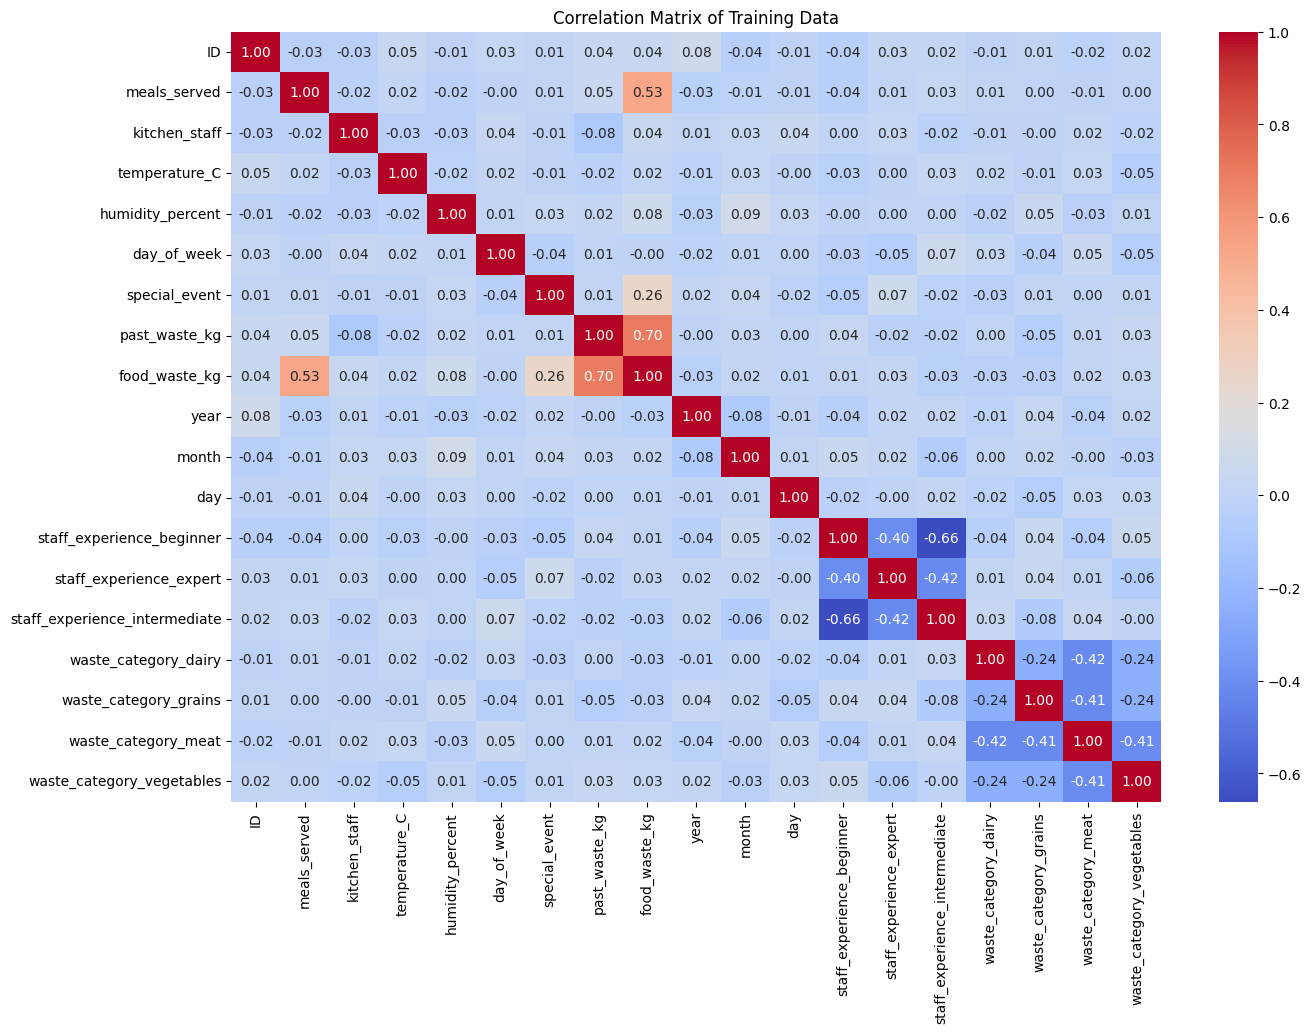

In [276]:
plt.figure(figsize=(15, 10))
sns.heatmap(train_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Training Data')
plt.show()

In [277]:
# Calculate correlations with the target variable 'food_waste_kg'
correlations = train_df.corr()['food_waste_kg'].sort_values(ascending=False)

# Display features with the highest correlation (excluding food_waste_kg itself)
print("Features with highest correlation to 'food_waste_kg':")
display(correlations[1:]) # Exclude food_waste_kg itself

Features with highest correlation to 'food_waste_kg':


,food_waste_kg
past_waste_kg,0.699184
meals_served,0.526783
special_event,0.260345
humidity_percent,0.077406
kitchen_staff,0.044145
ID,0.041162
waste_category_vegetables,0.032831
staff_experience_expert,0.026049
month,0.020523
waste_category_meat,0.018798


----
**STEP 6**

**SPLIT DATA**

----

In [278]:
X = train_df.drop(['food_waste_kg', 'ID'], axis=1)
y = train_df['food_waste_kg']

print("Shape of X (features):", X.shape)
print("Shape of y (target):", y.shape)

display(X.head())
display(y.head())

Shape of X (features): (887, 17)
Shape of y (target): (887,)


,meals_served,kitchen_staff,temperature_C,humidity_percent,day_of_week,special_event,past_waste_kg,year,month,day,staff_experience_beginner,staff_experience_expert,staff_experience_intermediate,waste_category_dairy,waste_category_grains,waste_category_meat,waste_category_vegetables
0,-0.928155,0.250778,0.627602,-0.895088,0,0,-1.518358,-1.083894,1.830175,0.382550,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,-0.506108,0.717599,-1.329794,0.203207,1,0,1.188423,0.176151,1.532091,0.608916,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-1.350202,0.951009,0.608332,0.469068,1,0,1.100146,-1.083894,-1.150664,-1.654740,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-1.271068,1.651240,-0.343149,-0.841522,6,0,1.128269,0.176151,-0.852581,0.382550,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.040097,-0.449453,0.459147,1.085097,0,0,-0.047609,-1.083894,0.339755,0.269367,0.0,0.0,1.0,0.0,0.0,1.0,0.0


,food_waste_kg
0,28.946465
1,51.549053
2,53.008323
3,48.621527
4,44.156984


----
**STEP 7**

**MODEL CREATION AND TRAIN**

----


In [279]:
# Initialize the Linear Regression model
linear_model = LinearRegression()

# Train the model using the training data
linear_model.fit(X, y)

LinearRegression()

----
**EVALUTE MODEL**

----

In [280]:
# Make predictions on the training data
y_pred = linear_model.predict(X)

# Calculate R-squared
r_squared = r2_score(y, y_pred)
print(f"R-squared: {r_squared:.4f}")

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")

# Compare actual vs. predicted values side-by-side for the training set
comparison_df = pd.DataFrame({'Actual': y, 'Predicted': y_pred})
print("\nActual vs. Predicted Food Waste (Training Set):")
display(comparison_df.head())

R-squared: 0.8130
Mean Squared Error (MSE): 25.3532

Actual vs. Predicted Food Waste (Training Set):


,Actual,Predicted
0,28.946465,21.532616
1,51.549053,47.269752
2,53.008323,43.592348
3,48.621527,43.641964
4,44.156984,39.800722


**RandomForestRegressor**

In [281]:
from sklearn.ensemble import RandomForestRegressor

RF = RandomForestRegressor(random_state=42)

RF.fit(X, y)

y_pred_RF = RF.predict(X)

# Calculate R-squared
r_squared = r2_score(y, y_pred_RF)
print(f"R-squared: {r_squared:.4f}")

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y, y_pred_RF)
print(f"Mean Squared Error (MSE): {mse:.4f}")

# Compare actual vs. predicted values side-by-side for the training set
comparison_df = pd.DataFrame({'Actual': y, 'Predicted': y_pred_RF})
print("\nActual vs. Predicted Food Waste (Training Set):")
display(comparison_df.head())

R-squared: 0.9705
Mean Squared Error (MSE): 4.0011

Actual vs. Predicted Food Waste (Training Set):


,Actual,Predicted
0,28.946465,25.810725
1,51.549053,50.192710
2,53.008323,50.504309
3,48.621527,45.559556
4,44.156984,43.895465


**GradientBoostingRegressor**

In [282]:
from sklearn.ensemble import GradientBoostingRegressor

GB = GradientBoostingRegressor(random_state=42)

GB.fit(X, y)

y_pred_GB = GB.predict(X)

# Calculate R-squared
r_squared = r2_score(y, y_pred_GB)
print(f"R-squared: {r_squared:.4f}")

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y, y_pred_GB)
print(f"Mean Squared Error (MSE): {mse:.4f}")

# Compare actual vs. predicted values side-by-side for the training set
comparison_df = pd.DataFrame({'Actual': y, 'Predicted': y_pred_GB})
print("\nActual vs. Predicted Food Waste (Training Set):")
display(comparison_df.head())

R-squared: 0.8969
Mean Squared Error (MSE): 13.9845

Actual vs. Predicted Food Waste (Training Set):


,Actual,Predicted
0,28.946465,24.333559
1,51.549053,48.942265
2,53.008323,46.111964
3,48.621527,45.557779
4,44.156984,42.721880


**KNeighborsRegressor**

In [283]:
from sklearn.neighbors import KNeighborsRegressor

KN = KNeighborsRegressor()

KN.fit(X, y)

y_pred_KN = KN.predict(X)

# Calculate R-squared
r_squared = r2_score(y, y_pred_KN)
print(f"R-squared (KNeighborsRegressor): {r_squared:.4f}")

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y, y_pred_KN)
print(f"Mean Squared Error (KNeighborsRegressor): {mse:.4f}")

# Compare actual vs. predicted values side-by-side for the training set
comparison_df_kn = pd.DataFrame({'Actual': y, 'Predicted': y_pred_KN})
print("\nActual vs. Predicted Food Waste (Training Set) - KNeighborsRegressor:")
display(comparison_df_kn.head())

R-squared (KNeighborsRegressor): 0.7333
Mean Squared Error (KNeighborsRegressor): 36.1585

Actual vs. Predicted Food Waste (Training Set) - KNeighborsRegressor:


,Actual,Predicted
0,28.946465,25.988437
1,51.549053,46.813388
2,53.008323,40.907788
3,48.621527,43.054647
4,44.156984,39.798917


In [284]:
comparison_df = pd.DataFrame({'Actual': y, 'PredictedLR': y_pred , 'PredictedRF': y_pred_RF ,'PredictedGB': y_pred_GB, 'PredictedKN': y_pred_KN})
print("\nActual vs. Predicted Food Waste (Training Set):")
display(comparison_df.head())
# Calculate R-squared
r_squared = r2_score(y, y_pred)
print(f"R-squared (Linear Regression): {r_squared:.4f}")
r_squared = r2_score(y, y_pred_RF)
print(f"R-squared (Random Forest): {r_squared:.4f}")
r_squared = r2_score(y, y_pred_GB)
print(f"R-squared (Gradient Boosting): {r_squared:.4f}")
r_squared = r2_score(y, y_pred_KN)
print(f"R-squared (KNeighborsRegressor): {r_squared:.4f}")

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y, y_pred)
print(f"Mean Squared Error (Linear Regression): {mse:.4f}")
mse = mean_squared_error(y, y_pred_RF)
print(f"Mean Squared Error (Random Forest): {mse:.4f}")
mse = mean_squared_error(y, y_pred_GB)
print(f"Mean Squared Error (Gradient Boosting): {mse:.4f}")
mse = mean_squared_error(y, y_pred_KN)
print(f"Mean Squared Error (KNeighborsRegressor): {mse:.4f}")


Actual vs. Predicted Food Waste (Training Set):


,Actual,PredictedLR,PredictedRF,PredictedGB,PredictedKN
0,28.946465,21.532616,25.810725,24.333559,25.988437
1,51.549053,47.269752,50.192710,48.942265,46.813388
2,53.008323,43.592348,50.504309,46.111964,40.907788
3,48.621527,43.641964,45.559556,45.557779,43.054647
4,44.156984,39.800722,43.895465,42.721880,39.798917


R-squared (Linear Regression): 0.8130
R-squared (Random Forest): 0.9705
R-squared (Gradient Boosting): 0.8969
R-squared (KNeighborsRegressor): 0.7333
Mean Squared Error (Linear Regression): 25.3532
Mean Squared Error (Random Forest): 4.0011
Mean Squared Error (Gradient Boosting): 13.9845
Mean Squared Error (KNeighborsRegressor): 36.1585


# FROM THE PREVIOS RESULTS RANDOMMFOREST IS THE BEST MODEL


---
# ENSEMBLE MODEL

---

### Combined Ensemble Model

In [285]:
from sklearn.ensemble import VotingRegressor

# Define the estimators for the VotingRegressor
# We are using the already trained individual models
en_estimators = [
    ('lr', linear_model),
    ('rf', RF),
    ('gb', GB),
    ('kn', KN)
]

# Create the VotingRegressor
voting_ensemble = VotingRegressor(estimators=en_estimators)

# Fit the voting ensemble model
voting_ensemble.fit(X, y)

# Make predictions with the voting ensemble
y_pred_voting_ensemble = voting_ensemble.predict(X)

# Calculate R-squared for the voting ensemble model
r_squared_voting_ensemble = r2_score(y, y_pred_voting_ensemble)
print(f"Voting Ensemble R-squared: {r_squared_voting_ensemble:.4f}")

# Calculate Mean Squared Error (MSE) for the voting ensemble model
mse_voting_ensemble = mean_squared_error(y, y_pred_voting_ensemble)
print(f"Voting Ensemble Mean Squared Error (MSE): {mse_voting_ensemble:.4f}")

# Compare actual vs. voting ensemble predicted values side-by-side for the training set
comparison_df_voting_ensemble = pd.DataFrame({'Actual': y, 'Voting_Ensemble_Predicted': y_pred_voting_ensemble})
print("\nActual vs. Voting Ensemble Predicted Food Waste (Training Set):")
display(comparison_df_voting_ensemble.head())

Voting Ensemble R-squared: 0.8929
Voting Ensemble Mean Squared Error (MSE): 14.5145

Actual vs. Voting Ensemble Predicted Food Waste (Training Set):


,Actual,Voting_Ensemble_Predicted
0,28.946465,24.416334
1,51.549053,48.304529
2,53.008323,45.279102
3,48.621527,44.453487
4,44.156984,41.554246


----
Generate Predictions on the Test Set

----

In [286]:
# Prepare the test data (drop 'ID' column to match training features X)
X_test = test_df.drop('ID', axis=1)

# Generate predictions using the Random Forest model
y_test_pred_rf = RF.predict(X_test)

# Create a DataFrame for the predictions with the original 'ID' from the test_df
predictions_df = pd.DataFrame({'ID': test_df['ID'], 'food_waste_kg': y_test_pred_rf})

# Save the predictions to a CSV file
predictions_filename = 'random_forest_predictions.csv'
predictions_df.to_csv(predictions_filename, index=False)

print(f"Predictions saved to {predictions_filename}")

# Provide a download link for the CSV file
from google.colab import files
files.download(predictions_filename)

print("First 10 predictions for the test set using Random Forest:")
display(predictions_df.head(10))

Predictions saved to random_forest_predictions.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

First 10 predictions for the test set using Random Forest:


,ID,food_waste_kg
0,0,25.810725
1,1,50.192710
2,4,50.504309
3,5,45.559556
4,6,43.895465
5,7,27.790336
6,8,49.571883
7,9,65.910256
8,10,41.478237
9,11,35.069884
